In [77]:
using JLD2
using Plots
using Statistics
using Printf

gr()


Plots.GRBackend()

In [78]:
cutoffs = ["1.0e-4", "1.0e-5", "1.0e-6", "1.0e-7", "1.0e-8", "1.0e-9", "1.0e-10", "1.0e-11", "1.0e-12", "1.0e-13", "1.0e-14"]
sigma_list = [0.2, 0.02, 0.002, 0.0002, 0.0]
filtered_sigmas = [s for s in sigma_list if s != 0.2]



data_dict = Dict()
results = Dict()

for c in cutoffs
    filename = joinpath(@__DIR__, "truncation_$(c).jld2")
    
    if isfile(filename)
        data = JLD2.load(filename)
        data_dict[c] = data
        
        results[c] = data["entanglement_results"]
        var_name = "results_" * replace(c, "-" => "_", "." => "_")
        eval(:($(Symbol(var_name)) = $(results[c])))
        
    else
        println("Warning: File $filename not found.")
    end
end



In [79]:
# obs_data[c][sigma][N]
energy_data = Dict()
sz_data = Dict()

for c in cutoffs
    file_path = joinpath(@__DIR__, "truncation_$(c).jld2")
    if isfile(file_path)
        jldopen(file_path, "r") do file
            energy_data[c] = read(file, "energy_results")
            sz_data[c] = read(file, "sz_results")
        end
    else
        println("Warning: File $file_path not found.")
    end
end

In [80]:
"""
Processes all observables across all cutoffs and sigmas.
  1. energy_density_all[cutoff][sigma][N]
  2. total_mag_all[cutoff][sigma][N]
"""
function calc_observables(energy_raw, sz_raw)
    energy_density_all = Dict()
    total_mag_all = Dict()
    
    for cutoff in keys(energy_raw)
        c_energy = Dict{Float64, Dict{Int, Float64}}()
        c_mag = Dict{Float64, Dict{Int, Float64}}()
        
        e_dict = energy_raw[cutoff]
        s_dict = sz_raw[cutoff]
        
        for σ in keys(e_dict)
            n_energy = Dict{Int, Float64}()
            n_mag = Dict{Int, Float64}()
            
            for N in keys(e_dict[σ])
                # Calculate Energy density: E / N
                n_energy[N] = e_dict[σ][N] / N
                
                # Calculate Total Magnetization: sum(Sz)
                n_mag[N] = sum(s_dict[σ][N])
            end
            c_energy[σ] = n_energy
            c_mag[σ] = n_mag
        end
        energy_density_all[cutoff] = c_energy
        total_mag_all[cutoff] = c_mag
    end
    
    return energy_density_all, total_mag_all
end

energy_density, total_mag = calc_observables(energy_data, sz_data)

(Dict{Any, Any}("1.0e-7" => Dict(0.0 => Dict(78 => -9.874986441530218, 56 => -7.124995861871332, 16 => -2.1249999999999987, 20 => -2.624999999999999, 58 => -7.374993650045763, 52 => -6.624995615285266, 60 => -7.624994427303884, 12 => -1.6249999999999998, 24 => -3.1249999999999996, 28 => -3.624999826565252…), 0.002 => Dict(78 => -9.874967320721181, 56 => -7.125149022735089, 16 => -2.1249375460627777, 20 => -2.6248955464828705, 58 => -7.3750467200037715, 52 => -6.625145336822983, 60 => -7.625059454740417, 12 => -1.6248810703739476, 24 => -3.124915684085926, 28 => -3.6247424182219055…), 0.2 => Dict(78 => -9.898926620423161, 56 => -7.1342456603273146, 16 => -2.1479853339879607, 20 => -2.6220372755042747, 58 => -7.377063627862799, 52 => -6.627575566262658, 60 => -7.627397235450667, 12 => -1.628100237262247, 24 => -3.1555989447814965, 28 => -3.620710337488511…), 0.02 => Dict(78 => -9.874321078580518, 56 => -7.125078973631426, 16 => -2.125685453889223, 20 => -2.6255471526805034, 58 => -7.3737

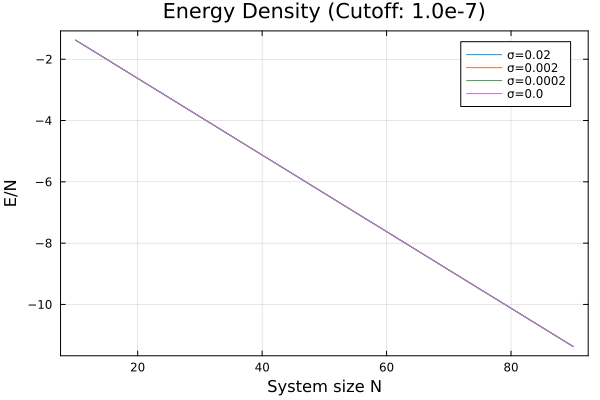

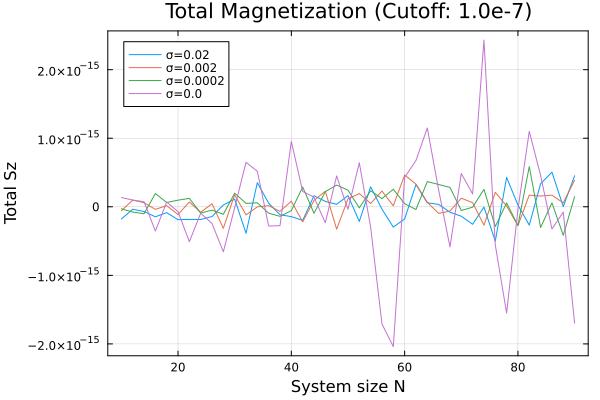

In [81]:
"""
Plots observables 
"""
function plot_observables(energy_all, mag_all, chosen_cutoff; sigmas_to_plot=nothing)
    if !haskey(energy_all, chosen_cutoff)
        error("Cutoff $chosen_cutoff not found in processed data.")
    end

    available_sigmas = collect(keys(energy_all[chosen_cutoff]))
    if sigmas_to_plot === nothing
        sigmas = sort(available_sigmas, rev=true)
    else
        sigmas = sort([s for s in sigmas_to_plot if s in available_sigmas], rev=true)
    end
    
    p1 = plot(title="Energy Density (Cutoff: $chosen_cutoff)",
              xlabel="System size N", ylabel="E/N", marker=:circle, grid=true, framestyle=:box)
              
    p2 = plot(title="Total Magnetization (Cutoff: $chosen_cutoff)",
              xlabel="System size N", ylabel="Total Sz", marker=:square, grid=true, framestyle=:box)

    for σ in sigmas
        Ns = sort(collect(keys(energy_all[chosen_cutoff][σ])))
        vals_e = [energy_all[chosen_cutoff][σ][N] for N in Ns]
        vals_m = [mag_all[chosen_cutoff][σ][N] for N in Ns]
        
        plot!(p1, Ns, vals_e, label="σ=$σ")
        plot!(p2, Ns, vals_m, label="σ=$σ")
    end
    
    p_energy = plot(p1)
    p_magnet = plot(p2)
    return (p_energy, p_magnet)
end


p_energy, p_magnet = plot_observables(energy_density, total_mag, "1.0e-7", sigmas_to_plot = filtered_sigmas)
display(p_energy)
display(p_magnet)

In [82]:
"""
Calculates the relative error of energy density compared to a reference cutoff.
"""
function calculate_convergence_errors(energy_density, reference_cutoff)
    if !haskey(energy_density, reference_cutoff)
        error("Reference cutoff $reference_cutoff not found in data.")
    end
    
    relative_errors = Dict()
    ref_data = energy_density[reference_cutoff]
    
    for cutoff in keys(energy_density)
        # Skip the reference itself
        if cutoff == reference_cutoff continue end
        
        c_errors = Dict{Float64, Dict{Int, Float64}}()
        
        for σ in keys(energy_density[cutoff])
            n_errors = Dict{Int, Float64}()
            
            for N in keys(energy_density[cutoff][σ])
                if haskey(ref_data, σ) && haskey(ref_data[σ], N)
                    e_val = energy_density[cutoff][σ][N]
                    e_ref = ref_data[σ][N]
                    
                    # Relative Error: |(val - ref) / ref|
                    # Using absolute values to ensure log plotting works
                    n_errors[N] = abs((e_val - e_ref) / e_ref)
                end
            end
            c_errors[σ] = n_errors
        end
        relative_errors[cutoff] = c_errors
    end
    
    return relative_errors
end


# the reference chosen is the finest cutoff available
reference = "1.0e-14"
conv_errors = calculate_convergence_errors(energy_density, reference)


Dict{Any, Any} with 10 entries:
  "1.0e-8"  => Dict(0.0=>Dict(78=>1.15964e-7, 56=>6.4221e-8, 16=>1.04492e-15, 2…
  "1.0e-12" => Dict(0.0=>Dict(78=>7.42904e-12, 56=>1.26551e-12, 16=>1.2539e-15,…
  "1.0e-11" => Dict(0.0=>Dict(78=>7.83059e-11, 56=>1.96987e-11, 16=>2.08983e-16…
  "1.0e-7"  => Dict(0.0=>Dict(78=>1.37301e-6, 56=>5.8079e-7, 16=>4.17966e-16, 2…
  "1.0e-5"  => Dict(0.0=>Dict(78=>0.000289084, 56=>0.000124044, 16=>1.2539e-15,…
  "1.0e-6"  => Dict(0.0=>Dict(78=>1.93782e-5, 56=>8.678e-6, 16=>1.2539e-15, 20=…
  "1.0e-4"  => Dict(0.0=>Dict(78=>0.0044377, 56=>0.00256882, 16=>0.000143165, 2…
  "1.0e-13" => Dict(0.0=>Dict(78=>5.6016e-13, 56=>3.50784e-13, 16=>2.08983e-16,…
  "1.0e-10" => Dict(0.0=>Dict(78=>9.53719e-10, 56=>2.87224e-10, 16=>2.08983e-16…
  "1.0e-9"  => Dict(0.0=>Dict(78=>1.11727e-8, 56=>5.416e-9, 16=>2.08983e-16, 20…

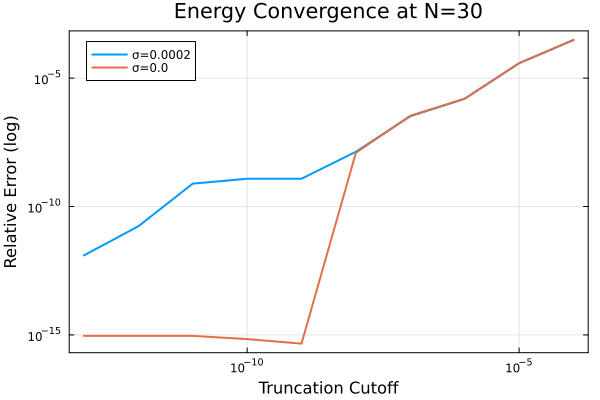

In [83]:
function plot_convergence_by_cutoff(error_data, target_N; sigmas_to_plot=nothing)
    p = plot(title = "Energy Convergence at N=$target_N",
             xlabel = "Truncation Cutoff", ylabel = "Relative Error (log)",
             xscale = :log10, yscale = :log10,
             marker = :circle, markersize=5, grid = true, 
             framestyle = :box, legend = :topleft)
    
    available_cutoffs = collect(keys(error_data))
    cutoff_vals = [parse(Float64, c) for c in available_cutoffs]
    perm = sortperm(cutoff_vals)
    sorted_cutoff_strings = available_cutoffs[perm]
    sorted_cutoff_floats = cutoff_vals[perm]

    first_cutoff = sorted_cutoff_strings[1]
    available_sigmas = collect(keys(error_data[first_cutoff]))
    sigmas = sigmas_to_plot === nothing ? 
             sort(available_sigmas, rev=true) : 
             sort([s for s in sigmas_to_plot if s in available_sigmas], rev=true)

    for σ in sigmas
        errors_y = Float64[]
        valid_x = Float64[]
        
        for (i, c_str) in enumerate(sorted_cutoff_strings)
            if haskey(error_data[c_str], σ) && haskey(error_data[c_str][σ], target_N)
                err = error_data[c_str][σ][target_N]
                
                # If the error is 0, we set it to a tiny floor value 
                # so it appears at the bottom of the log plot
                display_err = err == 0 ? 1e-16 : err
                
                push!(errors_y, display_err)
                push!(valid_x, sorted_cutoff_floats[i])
            end
        end
        
        if !isempty(errors_y)
            plot!(p, valid_x, errors_y, label="σ=$σ", linewidth=2)
        end
    end
    
    return p
end



p_conv = plot_convergence_by_cutoff(conv_errors, 30, sigmas_to_plot = filtered_sigmas)
display(p_conv)

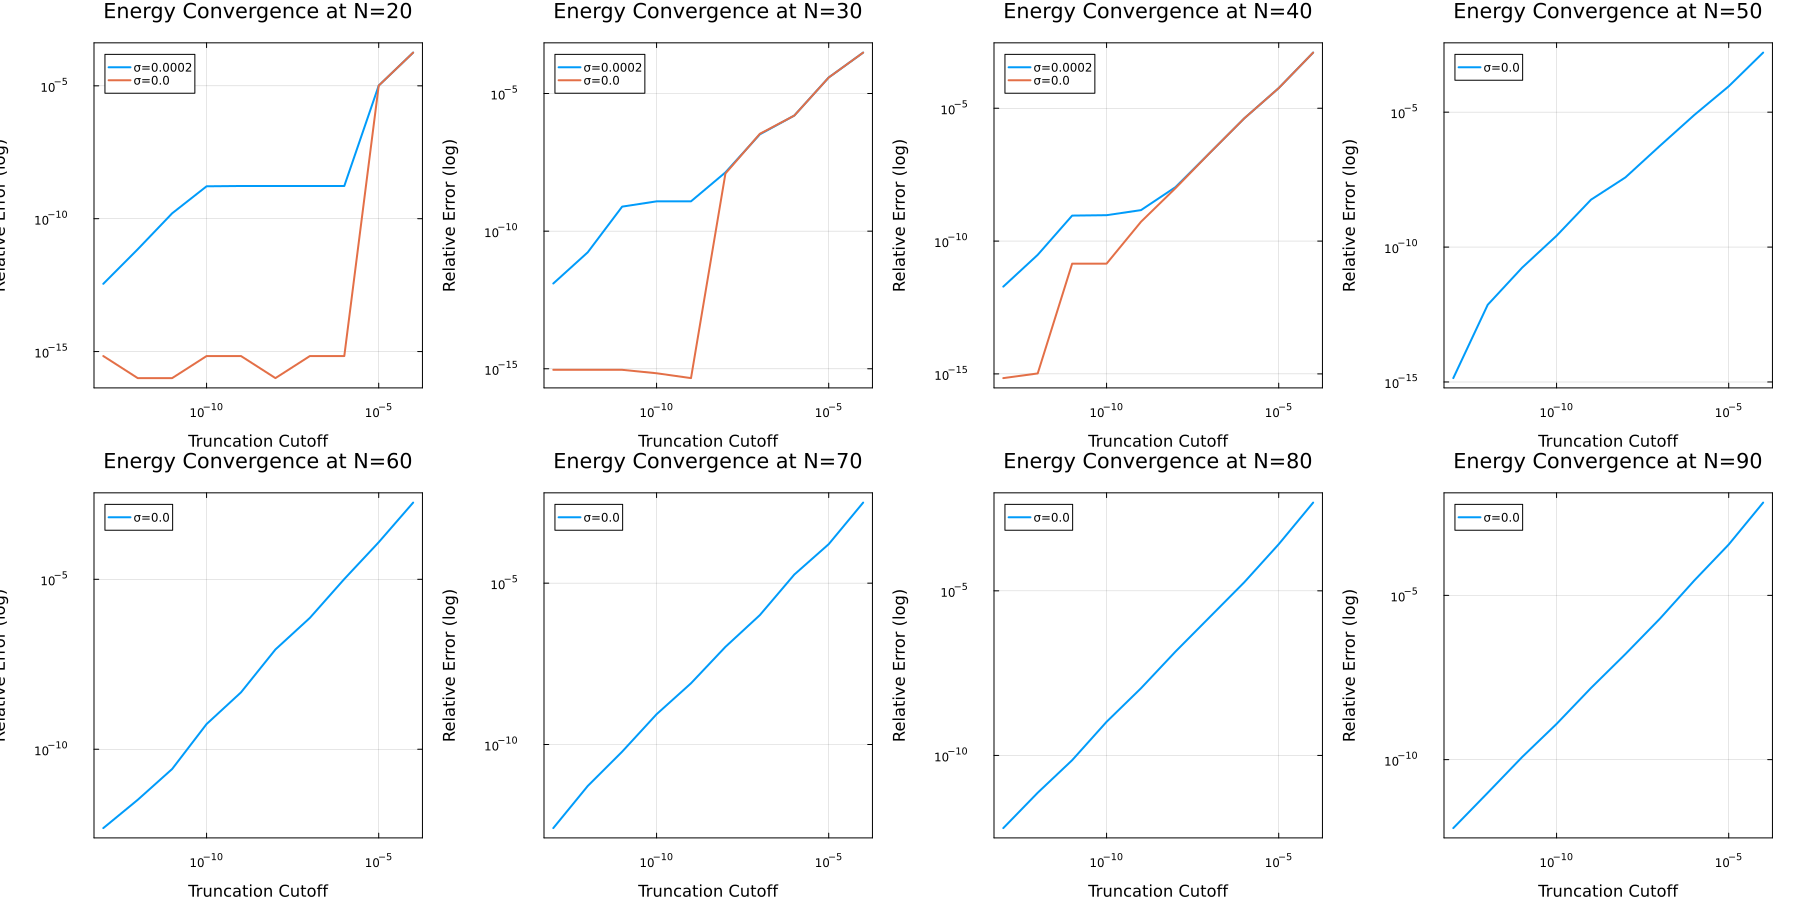

In [84]:
N_range = 20:10:90
plots_list = [plot_convergence_by_cutoff(conv_errors, n, sigmas_to_plot = filtered_sigmas) for n in N_range]
p_grid = plot(plots_list..., layout = (2, 4), size = (1800, 900), margin = 5Plots.mm)
display(p_grid)

understanding these plots

they show every sigma strength across the entire range of system sizes.
for flat lines at the 10^-16 scale, the simulation for that disorder is already fully converged to EPS
this happens for smaller systems or for low disorder, where bond dim is already low enough so truncation cut off doesnt cut off any meaningful information

as N increases, lines move upwards from the floor, indicating that the entanglement is growing and choice of cutoff has a measurable impact on the results


The reason why only sigma = 0.0 shows on the plots
for small systems, the simulation is apparently so accurate that the energy values for low disorder are identical to the reference values
When the code calculates abs(val - ref) / ref, it gets exactly 0.0. Since the y-axis is a log scale, the plotting library cannot render a value of zero , so it simply leaves those lines off the graph.
As $N$ increases to $90$, the system becomes more entangled and complex. eventually, only the $\sigma=0.0$ case remains "perfectly" converged at your chosen cutoffs, which is why it's the only line that disappears.

In [85]:
"""
Calculates the relative error for all N and sigmas.
"""
function calculate_global_stability(energy_density, reference_cutoff)
    if !haskey(energy_density, reference_cutoff)
        error("Reference cutoff $reference_cutoff not found.")
    end
    
    stability_results = Dict()
    ref_data = energy_density[reference_cutoff]
    
    for cutoff in keys(energy_density)
        if cutoff == reference_cutoff continue end
        
        c_map = Dict()
        for σ in keys(energy_density[cutoff])
            n_map = Dict{Int, Float64}()
            for N in keys(energy_density[cutoff][σ])
                if haskey(ref_data, σ) && haskey(ref_data[σ], N)
                    val = energy_density[cutoff][σ][N]
                    ref = ref_data[σ][N]
                    # Calculate relative error
                    n_map[N] = abs((val - ref) / ref)
                end
            end
            c_map[σ] = n_map
        end
        stability_results[cutoff] = c_map
    end
    return stability_results
end

stability_data = calculate_global_stability(energy_density, "1.0e-14")



Dict{Any, Any} with 10 entries:
  "1.0e-8"  => Dict{Any, Any}(0.0=>Dict(78=>1.15964e-7, 56=>6.4221e-8, 16=>1.04…
  "1.0e-12" => Dict{Any, Any}(0.0=>Dict(78=>7.42904e-12, 56=>1.26551e-12, 16=>1…
  "1.0e-11" => Dict{Any, Any}(0.0=>Dict(78=>7.83059e-11, 56=>1.96987e-11, 16=>2…
  "1.0e-7"  => Dict{Any, Any}(0.0=>Dict(78=>1.37301e-6, 56=>5.8079e-7, 16=>4.17…
  "1.0e-5"  => Dict{Any, Any}(0.0=>Dict(78=>0.000289084, 56=>0.000124044, 16=>1…
  "1.0e-6"  => Dict{Any, Any}(0.0=>Dict(78=>1.93782e-5, 56=>8.678e-6, 16=>1.253…
  "1.0e-4"  => Dict{Any, Any}(0.0=>Dict(78=>0.0044377, 56=>0.00256882, 16=>0.00…
  "1.0e-13" => Dict{Any, Any}(0.0=>Dict(78=>5.6016e-13, 56=>3.50784e-13, 16=>2.…
  "1.0e-10" => Dict{Any, Any}(0.0=>Dict(78=>9.53719e-10, 56=>2.87224e-10, 16=>2…
  "1.0e-9"  => Dict{Any, Any}(0.0=>Dict(78=>1.11727e-8, 56=>5.416e-9, 16=>2.089…

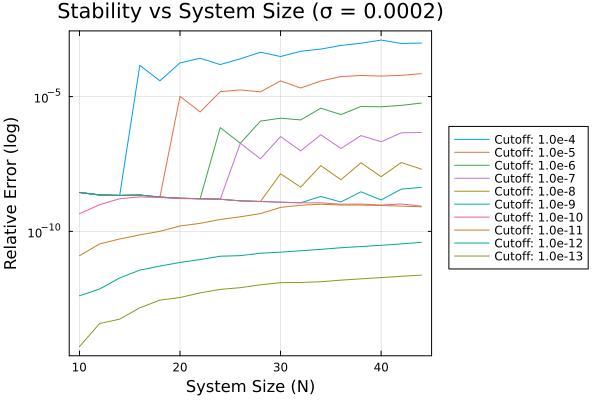

In [86]:


"""
plots the Error vs N for all cutoffs (at a fixed sigma).
Shows if error 'accumulates' as system size grows.
"""
function plot_error_growth(stability_results, target_sigma; sigmas_to_plot=nothing)
    p = plot(title = "Stability vs System Size (σ = $target_sigma)",
             xlabel = "System Size (N)", ylabel = "Relative Error (log)",
             yscale = :log10, marker = :circle, grid = true, 
             framestyle = :box, legend = :outerright)

    # Sort cutoffs numerically for the legend
    c_strs = sort(collect(keys(stability_results)), by=x->parse(Float64, x), rev=true)

    for c_str in c_strs
        if haskey(stability_results[c_str], target_sigma)
            Ns = sort(collect(keys(stability_results[c_str][target_sigma])))
            errs = [stability_results[c_str][target_sigma][N] for N in Ns]
            # Avoid plotting zeros on log scale
            valid_idx = findall(x -> x > 0, errs)
            plot!(p, Ns[valid_idx], errs[valid_idx], label="Cutoff: $c_str")
        end
    end
    return p
end



p_stable_low = plot_error_growth(stability_data, 0.0002)
display(p_stable_low)


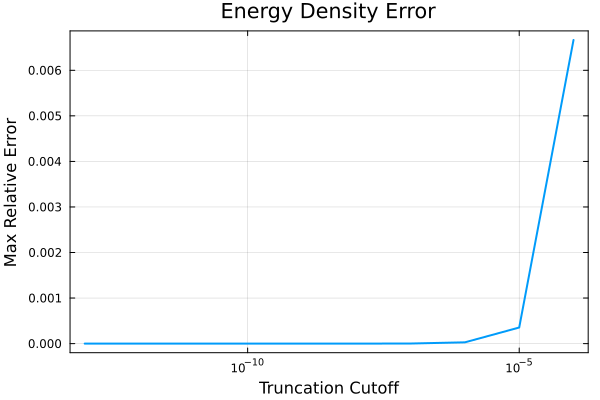

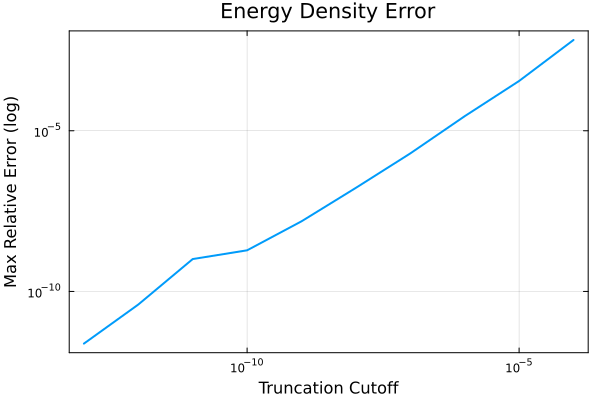

In [87]:




"""
Global Maximum Error.
Summarizes the 'worst' error found across ALL N for each cutoff.
"""
function plot_worst_case_stability(stability_results; sigmas_to_plot=nothing)
    p_log = plot(title = "Energy Density Error",
             xlabel = "Truncation Cutoff", ylabel = "Max Relative Error (log)",
             xscale = :log10, yscale = :log10, marker = :diamond, 
             markersize = 6, color = :red, grid = true, 
             framestyle = :box, legend = false)
    p_lin = plot(title = "Energy Density Error",
             xlabel = "Truncation Cutoff", ylabel = "Max Relative Error",
             xscale = :log10, marker = :diamond, 
             markersize = 6, color = :red, grid = true, 
             framestyle = :box, legend = false)

    c_strs = collect(keys(stability_results))
    c_vals = [parse(Float64, c) for c in c_strs]
    perm = sortperm(c_vals)
    
    sorted_floats = c_vals[perm]
    max_errs = Float64[]
    
    for c_str in c_strs[perm]
        m_err = 0.0
        # Determine sigmas to check
        available = collect(keys(stability_results[c_str]))
        sigmas = sigmas_to_plot === nothing ? available : [s for s in sigmas_to_plot if s in available]
        
        for σ in sigmas
            vals = collect(values(stability_results[c_str][σ]))
            if !isempty(vals)
                m_err = max(m_err, maximum(vals))
            end
        end
        push!(max_errs, m_err)
    end

    plot!(p_log, sorted_floats, max_errs, linewidth=2)
    plot!(p_lin, sorted_floats, max_errs, linewidth=2)
    return p_log, p_lin
end

p_worst_log, p_worst_lin = plot_worst_case_stability(stability_data, sigmas_to_plot = filtered_sigmas)
display(p_worst_lin)
display(p_worst_log)

What does this plot show?
- upper bound for error

for every truncation on the x axis, the function looks through all N = 20 to 90 system size and every disorder strength to find the absolute largest relative error which occured.

the x axis represents the truncations
the y axis shows the maximum error which was actually resulted

looks at the relationship between the cutoff and the output accuracy (energy density)